In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('IRIS.csv')
df.head()

C:\Users\Asus TUF\AppData\Local\Temp\ipykernel_21168\1569072761.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### 1. Statistik Deskriptif Atribut Angka
Menampilkan rata-rata (mean), standar deviasi (std), nilai min, max, serta kuartil (Q1, Q2/median, Q3) untuk kolom numerik.

In [2]:
df. describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 2. 10 Record Pertama Atribut Numerik
Mengambil 10 baris teratas Khusus untuk kolom bertipe angka

In [ ]:
df_angka = df.select_dtypes(include='number') # mengambil kolom dengan tipe data angka saja
df_angka.head(10) # menampilkan 10 data pertama

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


### 3. Informasi Struktur Dataset
Melihat dimensi data (jumlah record dan atribut), daftar nama atribut, serta jumlah atribut yang bertipe numerik.


In [4]:
jml_record = len(df) # jumlah data(baris)
jml_atribut = len(df.columns) # jumlah antribut (kolom)
nama_atribut = list(df.columns) # nama atribut
jml_atribut_angka = len(df.select_dtypes(include='number').columns) # jumlah atribut angka (kolom)

# menampilkan hasil
print(f"jumlah record                     : {jml_record}")
print(f"jumlah atribut                    : {jml_atribut}")
print(f"Nama atribut                      : {nama_atribut}")
print(f"jumlah atribut tipe angka         : {jml_atribut_angka}")


jumlah record                     : 150
jumlah atribut                    : 5
Nama atribut                      : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
jumlah atribut tipe angka         : 4


### 4. Jumlah Label pada Atribut Object
Menampilkan variasi label (kategori) dan jumlah data untuk masing-masing label pada kolom yang bertipe object (`species`).


In [ ]:
# Mengambil namaa kolom "spesies"
kolom_object = df.select_dtypes(include='object').columns


for col in kolom_object:
    print(f"Attribute: {col}") # kolom yang sedang di periksa
    print(f"Jumlah variasi label: {df[col].nunique()}") # data unik di kolom yang di periksa
    print("Jumlah data per label:")
    print(df[col].value_counts())  # menambil dataa unik dan jumlah nya di kolom
    print("-" * 35)


Attribute: species
Jumlah variasi label: 3
Jumlah data per label:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
-----------------------------------


### 5.1 Visualisasi 1: Bar Chart (Distribusi Jumlah Spesies)
Grafik ini digunakan untuk melihat persebaran jumlah record pada masing-masing spesies bunga Iris.


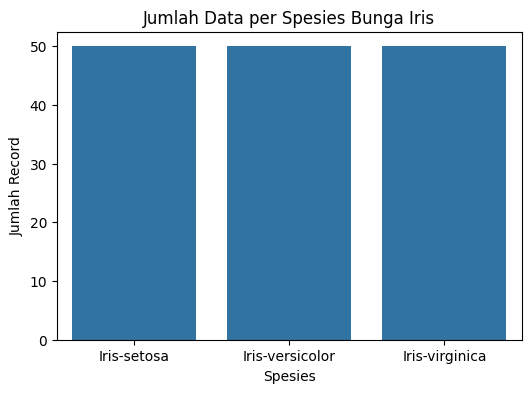

In [ ]:
plt.figure(figsize=(6, 4)) # ukuran gambar
sns.countplot(data=df, x='species') # data dan kolom nya
plt.title('Jumlah Data per Spesies Bunga Iris') # title
plt.xlabel('Spesies') # label di bagian bawah
plt.ylabel('Jumlah Record') # label di sebelah kiri
plt.show() # tambilkan grafik


### 5.2 Visualisasi 2: Scatter Plot (Petal Length vs Petal Width)
Grafik sebaran titik (scatter plot) untuk melihat pola hubungan antara panjang dan lebar mahkota (petal) berdasarkan jenis spesiesnya.


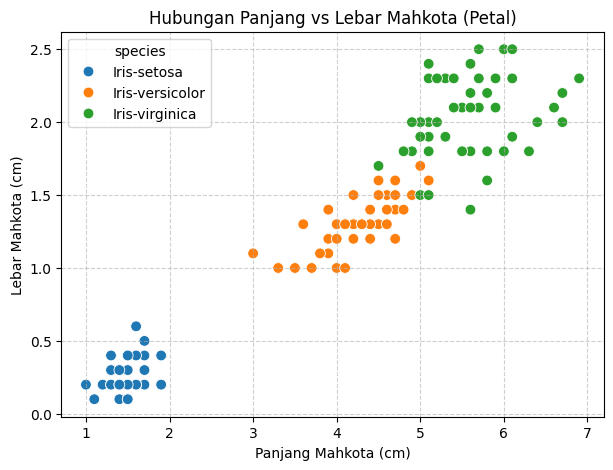

In [ ]:
plt.figure(figsize=(7, 5)) # ukuran gambar
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=60) # mengatur gambar seperti besar titik, spesies, dll
plt.title('Hubungan Panjang vs Lebar Mahkota (Petal)')
plt.xlabel('Panjang Mahkota (cm)') # label pada bagian bawa
plt.ylabel('Lebar Mahkota (cm)') # label pada bagian kiri
plt.grid(True, linestyle='--', alpha=0.6) # untuk memberika garis2 grid
plt.show() # membuat gambar


### 6. Matriks Korelasi dan Heatmap
Menghitung korelasi antar atribut numerik dan menampilkannya dalam bentuk heatmap untuk melihat keeratan hubungan antar atribut.


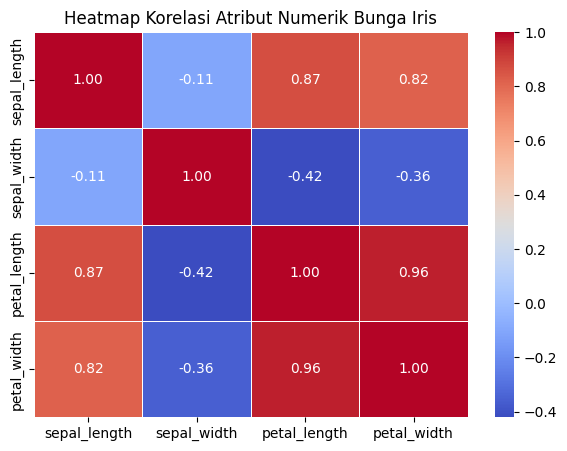

In [ ]:
korelasi = df.select_dtypes(include='number').corr() # menghitung matrix korelasi tanpa memasukan kolom spesies

plt.figure(figsize=(7, 5)) # ukuran gambar
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) # fungsi utama untuk menggambar heatmap nya
plt.title('Heatmap Korelasi Atribut Numerik Bunga Iris') # untuk membuat title
plt.show() # membuat gambar


### 7. Kesimpulan Hasil Eksplorasi Data
Berdasarkan eksplorasi yang telah dilakukan pada dataset Iris:
1. Dataset ini memiliki 150 data baris dan 5 kolom (4 numerik dan 1 kategorikal).
2. Data terdistribusi seimbang (balanced), di mana masing-masing spesies memiliki tepat 50 data.
3. Melalui visualisasi scatter plot, bunga *Iris-setosa* memiliki karakteristik yang sangat jelas terpisah dari dua spesies lainnya karena ukuran mahkotanya (petal) yang relatif jauh lebih kecil.
4. Dari analisis korelasi (heatmap), ditemukan korelasi positif yang sangat kuat antara `petal_length` dan `petal_width` (sebesar 0.96), yang menunjukkan bahwa pertumbuhan panjang dan lebar mahkota bunga berbanding lurus secara signifikan.
